<span style="color:#44f;font-weight:bold;">Codes for CNS2025: Lecture 13</span>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Entropy of a spike train

## Make a spike train with integrate-and-fire model

In [2]:
v0 = -70   # Resting potential (mV)
vr = -80   # Reset potential (mV)
sgm = 0.05 # Noise amplitude (mA s^{-1/2})
r = 50     # Input resistance (ohm)
bg = 0.3   # Background current (mA)
vth = -50  # Firing threshold (mV)
tau = 0.02 # Membrane time constant (s)
vi = -70   # Initial membrane potential (mV)
dt = 0.001 # Time between frames (s)

In [3]:
T = 4000 # Total time
v = vi # Initial state

# List for keeping traces
vs = []  # Membrane potential
ii = []  # Input stimulus current
ts = []  # Time
st = []  # Spike train

rng = np.random.default_rng(1234)
t = 0
while t<T:
    ic = sgm*rng.normal()/np.sqrt(dt)+bg # Input current
    v += dt*(v0-v+ic*r)/tau
    t += dt
    vs.append(v)
    ii.append(ic)
    ts.append(t)
    if v>vth:
        v = vr
        st.append(1)
    else: st.append(0)
ts = np.array(ts)  # Time points
vs = np.array(vs)  # Membrane potential
ii = np.array(ii)  # Input current
st = np.array(st)  # Spike train in frame-base representation

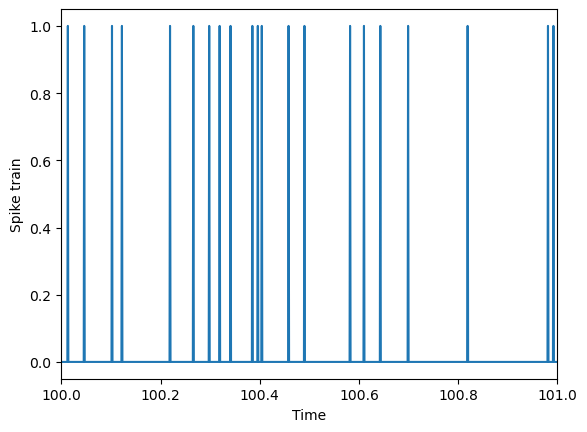

In [4]:
plt.plot(ts,st)
plt.ylabel('Spike train')
plt.xlim(100,101)
plt.xlabel('Time')
plt.show()

**Note:** This how the data file for the homework was created.

In [5]:
np.savez('hw13-data.npz',input_current=ii,spike_train=st,delta_t=dt)

# Calculate entropy of the spike train
The code below shows how to calculate the entropy of the spike train with code length $T_s = 10$.

In [6]:
with np.load('hw13-data.npz') as f:
    print(list(f))
    spike_train = f['spike_train']
    delta_t = f['delta_t']
delta_t
total_time = len(spike_train)*delta_t
print('Total time:',total_time)

['input_current', 'spike_train', 'delta_t']
Total time: 4000.0


In [7]:
# Calculate entropy of an array of probabilities
def entropy2(prob):
    b = prob[np.where(prob>0)]
    return -(b*np.log2(b)).sum()

In [8]:
print('Number of spikes:',np.array(spike_train).sum())

Number of spikes: 86402


In [9]:
Ts = 10 # Code length in unit of delta_t

In [10]:
occurance = {} # Use dict to keep the histogram of states
for i in range(len(spike_train)-Ts):
    b = tuple(spike_train[i:i+Ts]) # The state starting at i
    if not b in occurance: occurance[b] = 0
    occurance[b] += 1
counts = np.array(list(occurance.values())).astype(float)
print(f'There are {len(occurance)} different codes.')

There are 39 different codes.


In [11]:
# Same calculation using `numpy.unique`
counts_alt = np.unique([
    tuple(spike_train[i:i+Ts]) for i in range(len(spike_train)-Ts)
],axis=0,return_counts=True)[1]

In [12]:
np.all(counts.sort()==counts_alt.sort())

np.True_

In [13]:
prob = counts/counts.sum() # Normalize to get probability
entropy = entropy2(prob)/(Ts*delta_t) # Entropy rate
print(f'The entropy rate with code length {Ts=} is {entropy} bits/s.')

The entropy rate with code length Ts=10 is 147.50354755584843 bits/s.


<hr>
<address style="color:#44f;font-style:italic;font-weight:bold;"><a href="https://cc.tir.tw/wk/2025cns">CNS2025</a></address>